# EDA Report: UNSW-NB15 Training Set

This notebook provides a dataset overview, key visualizations, and identified data quality issues for the file `ml/UNSW_NB15_training-set.csv`.

**Contents**:
- Dataset overview
- Summary statistics and distributions
- Visualizations (protocols, services, numeric distributions, correlation)
- Data quality checks and issues
- Key insights and next steps

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set(style="whitegrid")
%matplotlib inline

In [3]:
# Load dataset
fp = 'UNSW_NB15_training-set.csv'
df = pd.read_csv(fp)
print('Shape:', df.shape)
display(df.head())
print(df.dtypes)

Shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [7]:
# Basic overview: missing values, duplicates, describe
print('Missing values per column:')
display(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())
display(df.describe(include='all').T)

Missing values per column:


id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,82332.0,NaN,NaN,NaN,41166.5,23767.345519,1.0,20583.75,41166.5,61749.25,82332.0
dur,82332.0,NaN,NaN,NaN,1.006756,4.710444,0.0,0.000008,0.014138,0.71936,59.999989
proto,82332,131,tcp,43095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,82332,13,-,47153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,82332,7,FIN,39339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spkts,82332.0,NaN,NaN,NaN,18.666472,133.916353,1.0,2.0,6.0,12.0,10646.0
dpkts,82332.0,NaN,NaN,NaN,17.545936,115.574086,0.0,0.0,2.0,10.0,11018.0
sbytes,82332.0,NaN,NaN,NaN,7993.908165,171642.26188,24.0,114.0,534.0,1280.0,14355774.0
dbytes,82332.0,NaN,NaN,NaN,13233.785563,151471.456091,0.0,0.0,178.0,956.0,14657531.0
rate,82332.0,NaN,NaN,NaN,82410.886739,148620.367041,0.0,28.606114,2650.176667,111111.1072,1000000.003


In [8]:
# Column types and cardinality for categorical features
cat_cols = ['proto','service','state','attack_cat']
for c in cat_cols:
    print(c, '-> unique:', df[c].nunique())
    display(df[c].value_counts().head(20))

proto -> unique: 131


proto
tcp        43095
udp        29418
unas        3515
arp          987
ospf         676
sctp         324
any           96
gre           88
rsvp          64
ipv6          61
sep           58
sun-nd        54
mobile        52
swipe         52
pim           52
prm           34
xns-idp       34
leaf-1        34
bbn-rcc       34
ggp           33
Name: count, dtype: int64

service -> unique: 13


service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29
dhcp           26
radius          9
irc             5
Name: count, dtype: int64

state -> unique: 7


state
FIN    39339
INT    34163
CON     6982
REQ     1842
ACC        4
RST        1
CLO        1
Name: count, dtype: int64

attack_cat -> unique: 10


attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

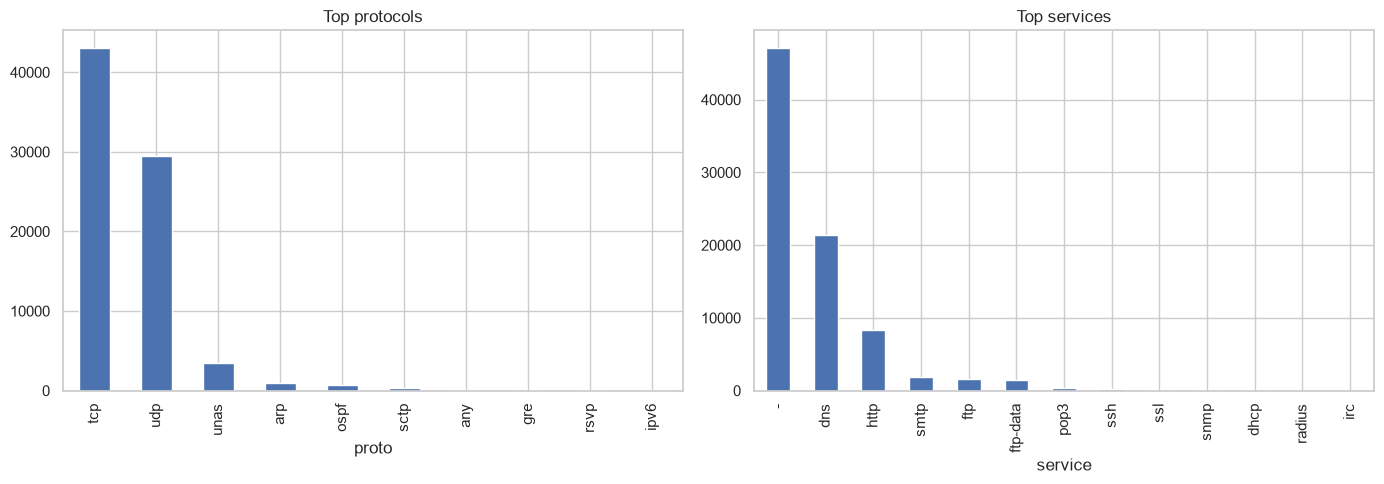

In [9]:
# Visual: top protocols and services
fig, axes = plt.subplots(1,2, figsize=(14,5))
df['proto'].value_counts().nlargest(10).plot(kind='bar', ax=axes[0])
axes[0].set_title('Top protocols')
df['service'].value_counts().nlargest(20).plot(kind='bar', ax=axes[1])
axes[1].set_title('Top services')
plt.tight_layout()

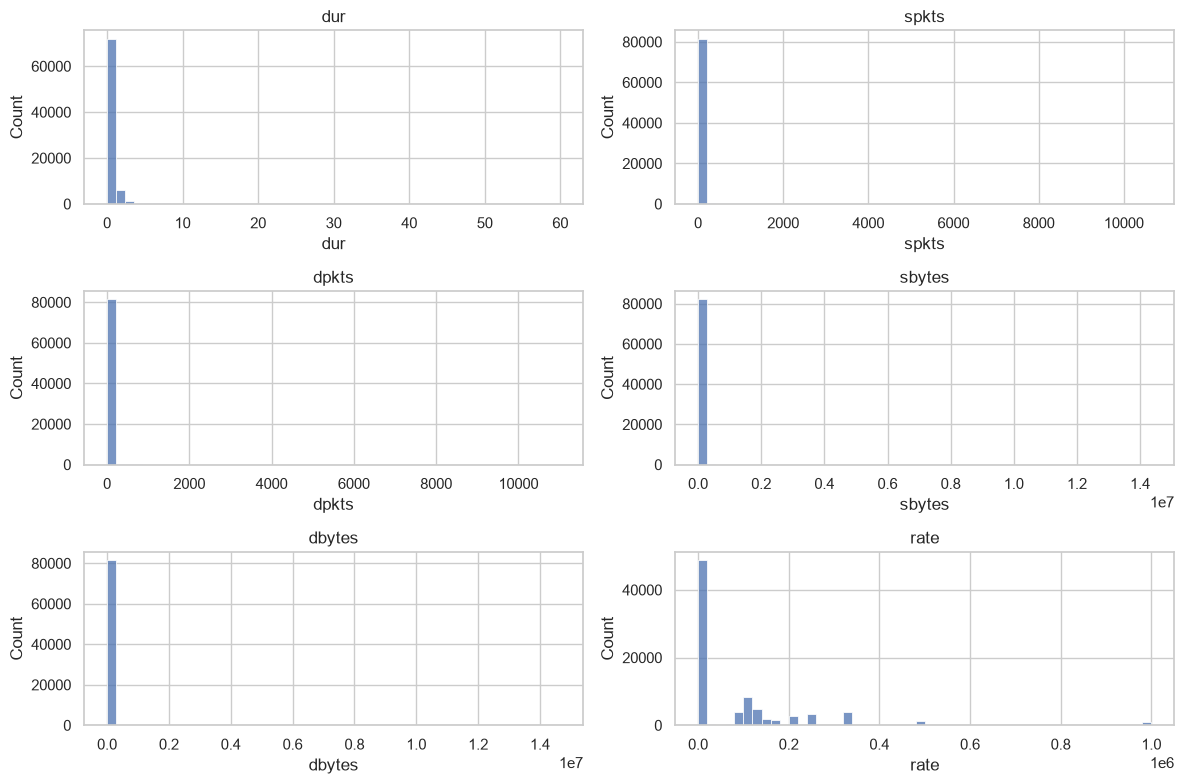

In [10]:
# Distribution plots for selected numeric columns
num_cols = ['dur','spkts','dpkts','sbytes','dbytes','rate']
plt.figure(figsize=(12,8))
for i,c in enumerate(num_cols,1):
    plt.subplot(3,2,i)
    sns.histplot(df[c].replace([np.inf, -np.inf], np.nan).dropna(), bins=50, kde=False)
    plt.title(c)
plt.tight_layout()

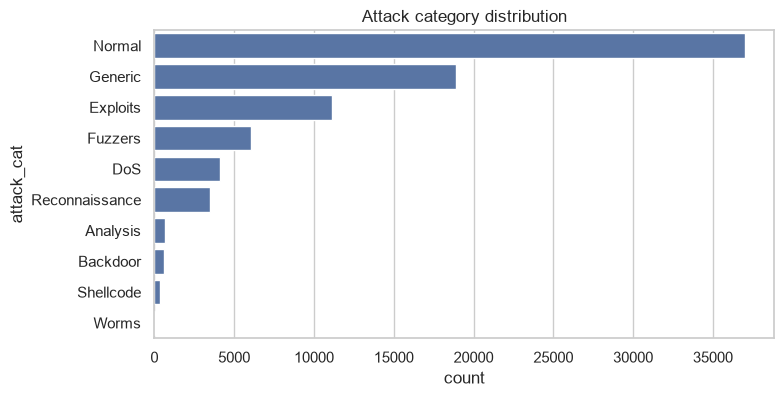

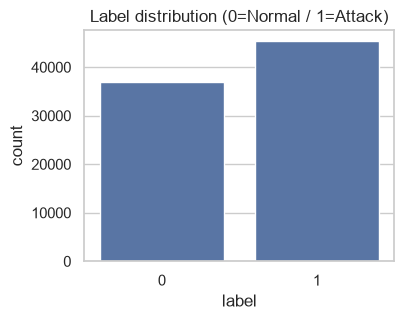

In [11]:
# Attack category distribution (if present)
if 'attack_cat' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(y='attack_cat', data=df, order=df['attack_cat'].value_counts().index)
    plt.title('Attack category distribution')
    plt.show()

# label distribution
plt.figure(figsize=(4,3))
sns.countplot(x='label', data=df)
plt.title('Label distribution (0=Normal / 1=Attack)')
plt.show()

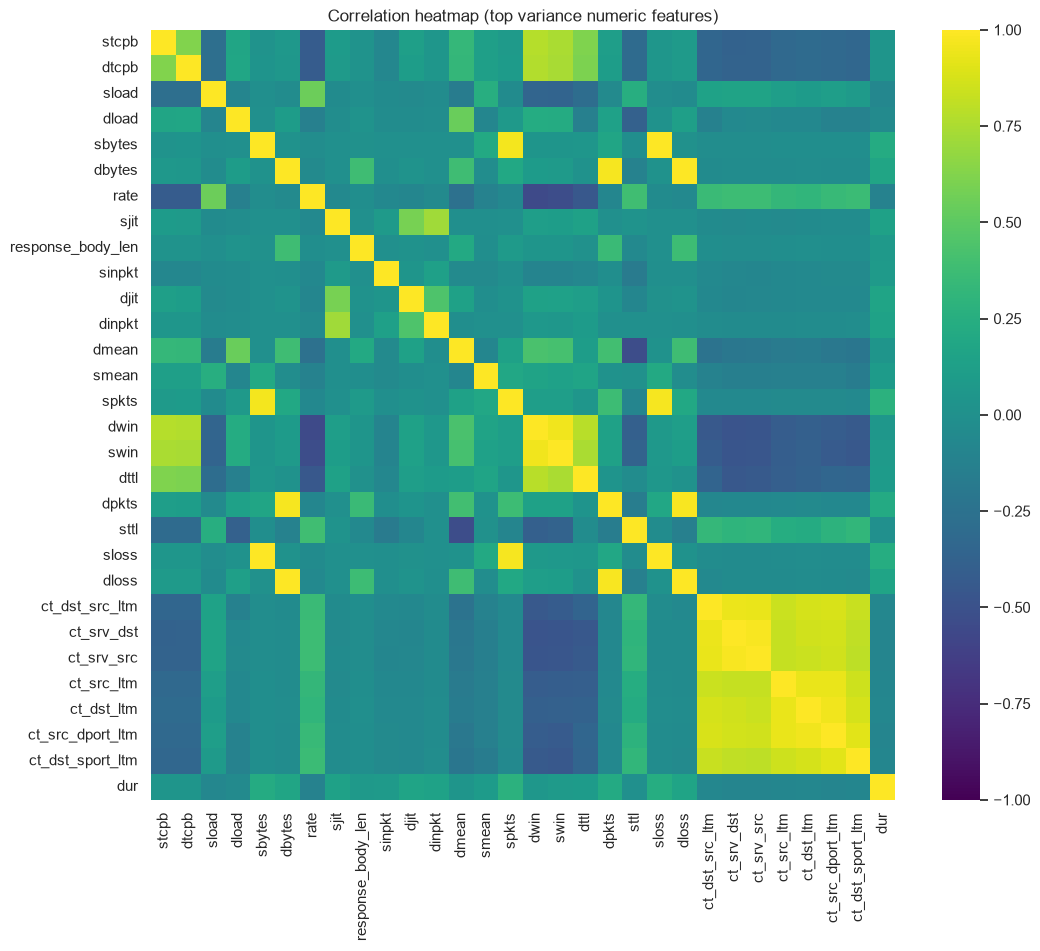

In [12]:
# Correlation heatmap for numeric subset (take top correlated features)
numeric = df.select_dtypes(include=[np.number]).copy()
# drop id-like or mostly-constant columns if present
if 'id' in numeric.columns:
    numeric = numeric.drop(columns=['id'])
corr = numeric.corr().abs()
# take a manageable subset of features (top by variance)
top_feats = numeric.var().sort_values(ascending=False).head(30).index
plt.figure(figsize=(12,10))
sns.heatmap(numeric[top_feats].corr(), cmap='viridis', vmax=1, vmin=-1)
plt.title('Correlation heatmap (top variance numeric features)')
plt.show()